# Data Preprocessing

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression

In [2]:
heart_data = pd.read_csv(r"C:\Users\user\Downloads\heart.csv")
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
heart_data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [4]:
heart_data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [5]:
heart_data['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

In [6]:
X = heart_data.drop(columns='target', axis=1)
y = heart_data['target']

In [7]:
print(X, y)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   3       145   233    1        0      150      0      2.3   
1     37    1   2       130   250    0        1      187      0      3.5   
2     41    0   1       130   204    0        0      172      0      1.4   
3     56    1   1       120   236    0        1      178      0      0.8   
4     57    0   0       120   354    0        1      163      1      0.6   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   57    0   0       140   241    0        1      123      1      0.2   
299   45    1   3       110   264    0        1      132      0      1.2   
300   68    1   0       144   193    1        1      141      0      3.4   
301   57    1   0       130   131    0        1      115      1      1.2   
302   57    0   1       130   236    0        0      174      0      0.0   

     slope  ca  thal  
0        0   0     1  
1        0   0     2  
2        2   0    

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2)

In [9]:
print(X.shape, X_train.shape, X_test.shape)

(303, 13) (242, 13) (61, 13)


In [10]:
lr = LogisticRegression(max_iter=1000)

In [11]:
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

# Accuracy Score

In [12]:
train_pred = lr.predict(X_train)
train_acc = accuracy_score(train_pred, y_train)
print(f'Accuracy of train data: {train_acc}')

Accuracy of train data: 0.8553719008264463


In [13]:
test_pred = lr.predict(X_test)
test_acc = accuracy_score(test_pred, y_test)
print(f'Accuracy of test data: {test_acc}')

Accuracy of test data: 0.8032786885245902


# Confusion Matrix

In [14]:
cf_matrix = confusion_matrix(y_test, test_pred)
cf_matrix

array([[22,  6],
       [ 6, 27]])

In [15]:
tn, fp, fn, tp = cf_matrix.ravel()

In [16]:
print(tn, fp, fn, tp)

22 6 6 27


Text(50.722222222222214, 0.5, 'Actual Labels')

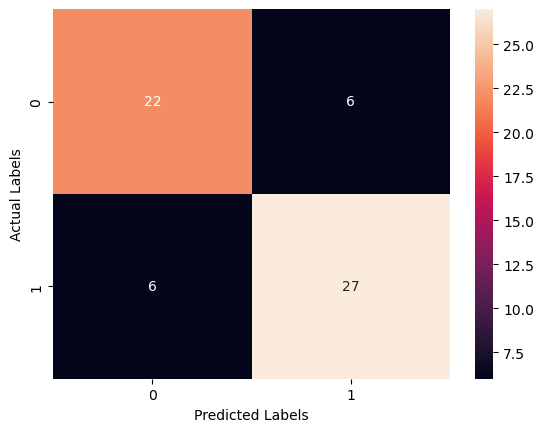

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cf_matrix, annot=True)
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')

# Precision, Recall, F1 Score

In [20]:
# Precision
from sklearn.metrics import precision_score

train_precision = precision_score(y_train, train_pred)
test_precision = precision_score(y_test, test_pred)

print(f'Precision for train data: {train_precision}')
print(f'Precision for test data: {test_precision}')

Precision for train data: 0.8299319727891157
Precision for test data: 0.8181818181818182


In [28]:
# Recall
from sklearn.metrics import recall_score

train_recall = recall_score(y_train, train_pred)
test_recall = recall_score(y_test, test_pred)

print(f'Recall for train data: {train_recall}')
print(f'Recall for test data: {test_recall}')

Recall for train data: 0.9242424242424242
Recall for test data: 0.8181818181818182


In [29]:
# F1 Score
from sklearn.metrics import f1_score

train_f1 = f1_score(y_train, train_pred)
test_f1 = f1_score(y_test, test_pred)

print(f'F1 Score for train data: {train_f1}')
print(f'F1 Score for test data: {test_f1}')

F1 Score for train data: 0.8745519713261649
F1 Score for test data: 0.8181818181818182


In [23]:
def precision_recall_f1_score(true_labels, predicted_labels):
    precision = precision_score(true_labels, predicted_labels)
    recall = recall_score(true_labels, predicted_labels)
    f1 = f1_score(true_labels, predicted_labels)

    print(f'Precision: {precision}')
    print(f'Recall: {recall}')
    print(f'F1 Score: {f1}')

In [24]:
precision_recall_f1_score(y_train, train_pred)

Precision: 0.8299319727891157
Recall: 0.9242424242424242
F1 Score: 0.8745519713261649


In [25]:
precision_recall_f1_score(y_test, test_pred)

Precision: 0.8181818181818182
Recall: 0.8181818181818182
F1 Score: 0.8181818181818182
